<a href="https://colab.research.google.com/github/ambatitarunsrisai-DA/Laptop-Data-Analysis/blob/main/Laptop_Data_Analysis.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [12]:
# Install missing libraries if needed
!pip install pandas numpy matplotlib seaborn plotly

# Import libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px


In [3]:
from google.colab import files
uploaded = files.upload()

df = pd.read_csv("laptop (1).csv")

Saving laptop.csv to laptop (1).csv


In [4]:
# Drop duplicate rows if any
df = df.drop_duplicates()

# Handle missing values
print(df.isnull().sum())

# Fill missing numeric values with median, categorical with mode
for col in df.columns:
    if df[col].dtype == 'object':
        df[col].fillna(df[col].mode()[0], inplace=True)
    else:
        df[col].fillna(df[col].median(), inplace=True)


Unnamed: 0           0
Brand                0
Name                 0
Price                0
Processor_Name       0
Processor_Brand      0
RAM_Expandable       0
RAM                  0
RAM_TYPE             0
Ghz                  0
Display_type         0
Display              0
GPU                  8
GPU_Brand            4
SSD                  0
HDD                  0
Adapter              0
Battery_Life       418
dtype: int64


/tmp/ipython-input-1887238666.py:12: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df[col].fillna(df[col].median(), inplace=True)
/tmp/ipython-input-1887238666.py:10: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try us

In [5]:
df.describe(include='all').T



,count,unique,top,freq,mean,std,min,25%,50%,75%,max
Unnamed: 0,3976.0,NaN,NaN,NaN,2181.495724,1297.029657,0.0,1058.75,2098.5,3342.25,4408.0
Brand,3976,31,ASUS,989,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Name,3976,3941,ASUS TUF Gaming A15 FA506IHRZ-HN113W Laptop (1...,2,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Price,3976.0,NaN,NaN,NaN,72432.528672,52207.650948,7990.0,39873.25,58990.0,84990.0,503890.0
Processor_Name,3976,125,Intel Core i5 (11th Gen),316,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Processor_Brand,3976,19,Intel,3009,NaN,NaN,NaN,NaN,NaN,NaN,NaN
RAM_Expandable,3976,10,Not Expandable,2157,NaN,NaN,NaN,NaN,NaN,NaN,NaN
RAM,3976,20,8 GB,1608,NaN,NaN,NaN,NaN,NaN,NaN,NaN
RAM_TYPE,3976,19,DDR4 RAM,1505,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Ghz,3976,31,4.2 Ghz Processor,331,NaN,NaN,NaN,NaN,NaN,NaN,NaN


/tmp/ipython-input-191033083.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=brand_counts.index, y=brand_counts.values, palette="viridis")


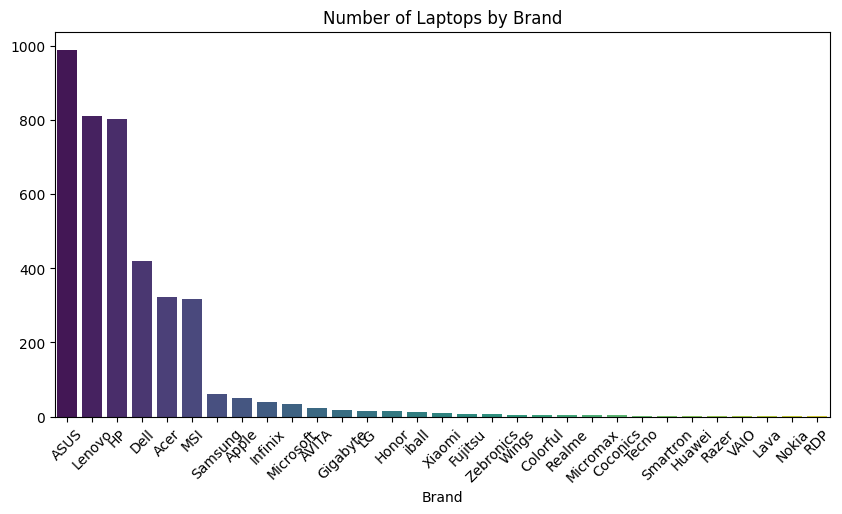

In [6]:
brand_counts = df['Brand'].value_counts()
plt.figure(figsize=(10,5))
sns.barplot(x=brand_counts.index, y=brand_counts.values, palette="viridis")
plt.title("Number of Laptops by Brand")
plt.xticks(rotation=45)
plt.show()


/tmp/ipython-input-59712005.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=avg_price_brand.index, y=avg_price_brand.values, palette="coolwarm")


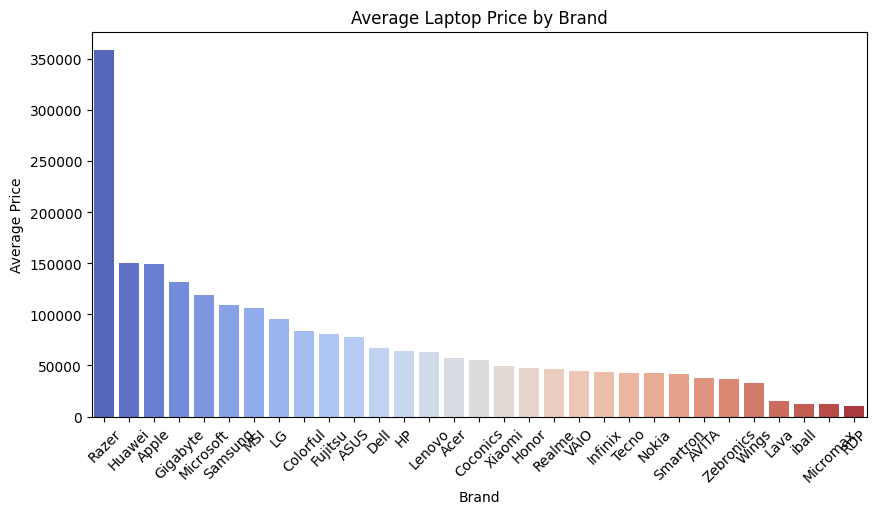

In [7]:
avg_price_brand = df.groupby('Brand')['Price'].mean().sort_values(ascending=False)
plt.figure(figsize=(10,5))
sns.barplot(x=avg_price_brand.index, y=avg_price_brand.values, palette="coolwarm")
plt.title("Average Laptop Price by Brand")
plt.xticks(rotation=45)
plt.ylabel("Average Price")
plt.show()


/tmp/ipython-input-3469081767.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(


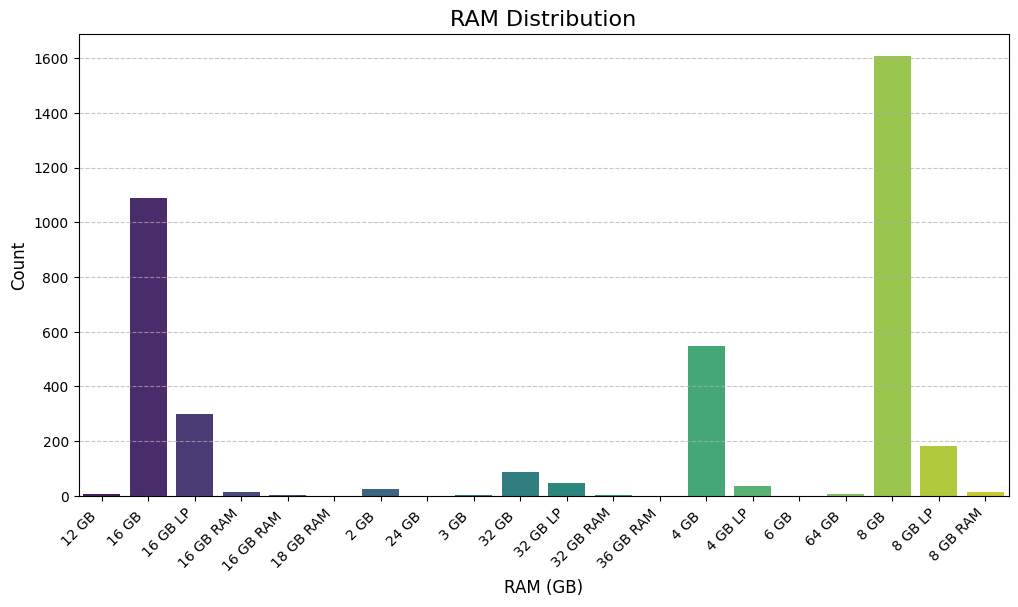

In [8]:
plt.figure(figsize=(12,6))  # make it larger
sns.countplot(
    x='RAM',
    data=df,
    order=sorted(df['RAM'].unique()),
    palette='viridis'
)
plt.title("RAM Distribution", fontsize=16)
plt.xlabel("RAM (GB)", fontsize=12)
plt.ylabel("Count", fontsize=12)
plt.xticks(rotation=45, ha='right')  # rotate for clarity
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()


/tmp/ipython-input-191033083.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=brand_counts.index, y=brand_counts.values, palette="viridis")


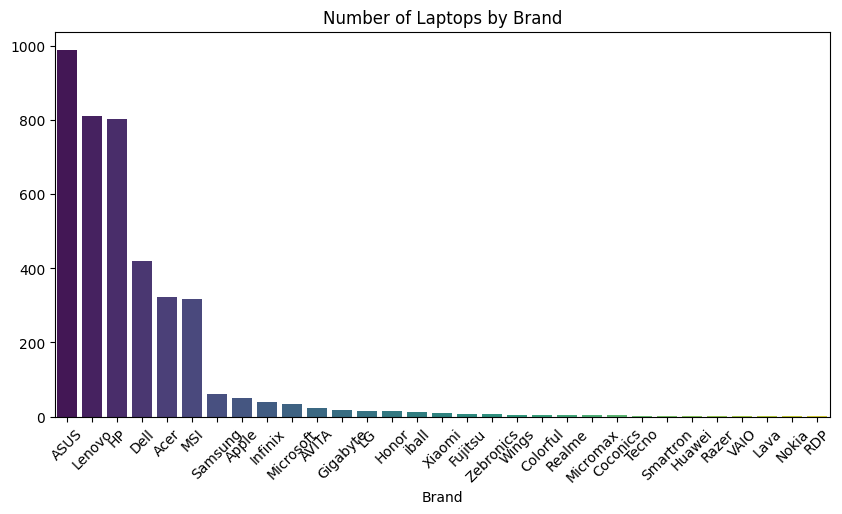

In [9]:
brand_counts = df['Brand'].value_counts()
plt.figure(figsize=(10,5))
sns.barplot(x=brand_counts.index, y=brand_counts.values, palette="viridis")
plt.title("Number of Laptops by Brand")
plt.xticks(rotation=45)
plt.show()


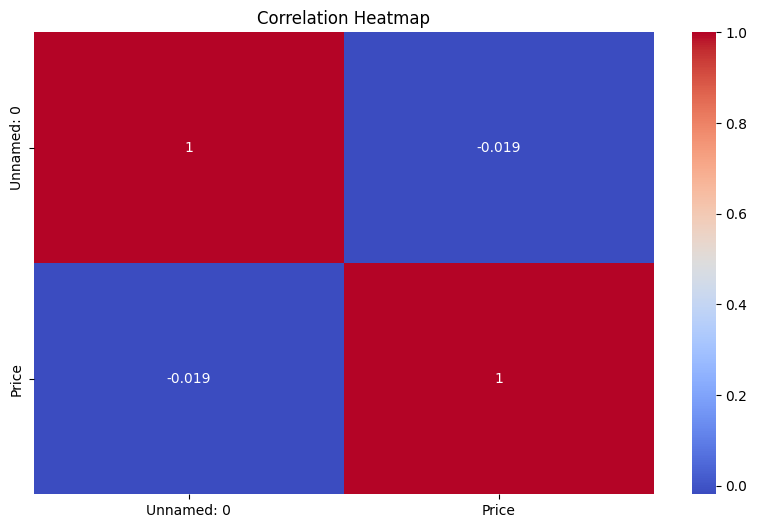

In [10]:
plt.figure(figsize=(10,6))
sns.heatmap(df.corr(numeric_only=True), annot=True, cmap="coolwarm")
plt.title("Correlation Heatmap")
plt.show()


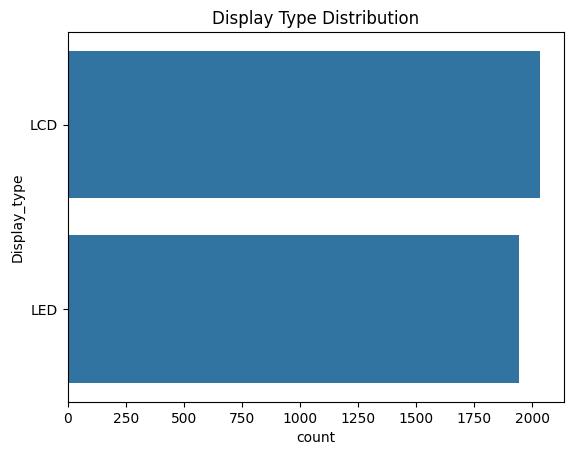

In [11]:
sns.countplot(y='Display_type', data=df, order=df['Display_type'].value_counts().index)
plt.title("Display Type Distribution")
plt.show()
